# Assignment: Matrix Multiplication Performance with Cython

**Course:** EE2703 - Applied Programming Laboratory  
**Topic:** Introduction to Cython for Performance Optimization

---

## Learning Objectives

In this assignment, you will:
1. Profile pure Python matrix multiplication code
2. Progressively optimize it using Cython techniques
3. Compare performance against NumPy's optimized implementation
4. Understand when and why to use Cython

## Instructions

1. **Complete all sections** marked with `# YOUR CODE HERE`
2. **Run all cells in order** - Use "Restart & Run All" before submission
3. **Fill in the analysis sections** with your observations
4. **Submit this notebook** with all outputs visible

---

## Setup

If you are running this on the JupyterLab server https://jup.dev.iitm.ac.in/ all the required modules are already present and you should not need anything new installed.  The final code will be evaluated on this machine, so in case you use any modules not present there your code may not work.  You can temporarily work on a Google colab notebook if you find that comfortable, but keep in mind that final evaluation will be on the Jup server.

If you are running it on your own system, you *may* need to install the following packages:

```bash
pip install setuptools cython numpy pandas matplotlib jupyter
```

The template code has been written assuming you will use a notebook that supports the `%%cython` magic commands.  Hence, a plain Python script will **NOT** be acceptable.

In [23]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Cython magic
%load_ext cython

print("Setup complete!")

The cython extension is already loaded. To reload it, use:
  %reload_ext cython
Setup complete!


## Part 1: Baseline Python Implementation

Implement a simple matrix multiplication function in pure Python using nested loops. This should be similar to what you did in your first assignment.

**Requirements:**
- Use three nested loops (i, j, k)
- No NumPy or other libraries
- Handle matrices as lists of lists

In [24]:
def matmul_python(A, B):
    """
    Pure Python matrix multiplication.

    Args:
        A: Matrix of size (m, n) as list of lists
        B: Matrix of size (n, p) as list of lists

    Returns:
        Result matrix of size (m, p) as list of lists
    """

    m = len(A)
    n = len(A[0])
    p = len(B[0])
    C = [[0 for _ in range(p)] for _ in range(m)]
    for i in range(m):
        for j in range(p):
            total = 0
            for k in range(n):
                total += A[i][k] * B[k][j]
            C[i][j] = total
    return C

### Test the Implementation

In [25]:
# Small test to verify correctness
A_test = [[1, 2], [3, 4]]
B_test = [[5, 6], [7, 8]]
C_test = matmul_python(A_test, B_test)

print("Test multiplication:")
print(f"A = {A_test}")
print(f"B = {B_test}")
print(f"C = {C_test}")
print(f"\nExpected: [[19, 22], [43, 50]]")

# Verify with NumPy
A_np = np.array(A_test)
B_np = np.array(B_test)
C_np = A_np @ B_np
print(f"NumPy result: {C_np.tolist()}")

Test multiplication:
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
C = [[19, 22], [43, 50]]

Expected: [[19, 22], [43, 50]]
NumPy result: [[19, 22], [43, 50]]


### Timing Function

We'll use this helper function to time all implementations.

In [26]:
def time_matmul(func, A, B, name="", runs=3):
    """
    Time a matrix multiplication function.
    
    Args:
        func: Function to time
        A, B: Input matrices
        name: Name for display
        runs: Number of runs to average
    
    Returns:
        Average time in seconds
    """
    times = []
    for _ in range(runs):
        start = time.time()
        result = func(A, B)
        elapsed = time.time() - start
        times.append(elapsed)
    
    avg_time = sum(times) / len(times)
    print(f"{name:30s}: {avg_time:.4f} seconds")
    return avg_time

### Benchmark Python Implementation

Test with different matrix sizes.

In [30]:
# Create test matrices of different sizes
sizes = [64, 128, 256, 512]
python_times = []

print("Benchmarking Pure Python Implementation")
print("=" * 50)

for size in sizes:
    # Create random matrices as lists
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_python, A, B, f"Python {size}x{size}")
    python_times.append(t)

Benchmarking Pure Python Implementation

Size 64x64:
Python 64x64                  : 0.0390 seconds

Size 128x128:
Python 128x128                : 0.2038 seconds

Size 256x256:
Python 256x256                : 1.7823 seconds

Size 512x512:
Python 512x512                : 20.3321 seconds


---

## Part 2: Cython Level 1 - Basic Compilation

In this level, we simply compile the Python code with Cython without any modifications. This gives us a baseline for Cython's improvement.

**Task:** Copy your Python function into the Cython cell below (with `%%cython` magic).

In [31]:
%%cython

def matmul_cython_level1(A, B):
    """
    Level 1: Pure Python code compiled with Cython.
    No optimizations, just basic compilation.
    """

    m = len(A)
    n = len(A[0])
    p = len(B[0])
    C = [[0 for _ in range(p)] for _ in range(m)]
    for i in range(m):
        for j in range(p):
            total = 0
            for k in range(n):
                total += A[i][k] * B[k][j]
            C[i][j] = total
    return C


### Benchmark Level 1

In [32]:
cython_level1_times = []

print("Benchmarking Cython Level 1 (Basic Compilation)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level1, A, B, f"Cython L1 {size}x{size}")
    cython_level1_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking Cython Level 1 (Basic Compilation)

Size 64x64:
Cython L1 64x64               : 0.0085 seconds
  Speedup vs Python: 4.57x

Size 128x128:
Cython L1 128x128             : 0.0757 seconds
  Speedup vs Python: 2.69x

Size 256x256:
Cython L1 256x256             : 0.7756 seconds
  Speedup vs Python: 2.30x

Size 512x512:
Cython L1 512x512             : 9.5367 seconds
  Speedup vs Python: 2.13x


---

## Part 3: Cython Level 2 - Type Declarations

Now we add static type declarations to help Cython generate efficient C code.

**Key optimizations:**
- Use `cdef` to declare loop variables as integers
- Declare matrix dimensions as integers
- Use `cdef` for the accumulator variable

**Task:** Add type declarations to your code.

In [33]:
%%cython

def matmul_cython_level2(A, B):
    """
    Level 2: Add static type declarations.
    This allows Cython to generate more efficient C code.
    """

    cdef int m = len(A)
    cdef int n = len(A[0])
    cdef int p = len(B[0])
    cdef int i, j, k
    cdef double total
    C = [[0 for _ in range(p)] for _ in range(m)]
    for i in range(m):
        for j in range(p):
            total = 0.0
            for k in range(n):
                total += A[i][k] * B[k][j]
            C[i][j] = total
    return C


### Benchmark Level 2

In [10]:
cython_level2_times = []

print("Benchmarking Cython Level 2 (Type Declarations)")
print("=" * 50)

for size in sizes:
    A = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    B = [[float(np.random.rand()) for _ in range(size)] for _ in range(size)]
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level2, A, B, f"Cython L2 {size}x{size}")
    cython_level2_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 1: {cython_level1_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 2 (Type Declarations)

Size 64x64:
Cython L2 64x64               : 0.0164 seconds
  Speedup vs Python: 1.44x
  Speedup vs Level 1: 0.55x

Size 128x128:
Cython L2 128x128             : 0.0889 seconds
  Speedup vs Python: 2.33x
  Speedup vs Level 1: 0.84x

Size 256x256:
Cython L2 256x256             : 0.9501 seconds
  Speedup vs Python: 1.78x
  Speedup vs Level 1: 0.87x

Size 512x512:
Cython L2 512x512             : 12.7621 seconds
  Speedup vs Python: 1.53x
  Speedup vs Level 1: 0.95x


---

## Part 4: Cython Level 3 - NumPy Arrays with Memory Views

The biggest speedup comes from using NumPy arrays with Cython's memory views. This allows direct access to array data without Python overhead.

**Key optimizations:**
- Accept NumPy arrays as input (not lists)
- Use memory view syntax: `double[:, :]` for 2D arrays
- Add compiler directives to disable safety checks - `boundscheck` and `wraparound` are useful decorators

**Task:** Implement the fully optimized version using memory views.

In [34]:
%%cython
import numpy as np
cimport numpy as np
cimport cython

@cython.boundscheck(False)
@cython.wraparound(False)
def matmul_cython_level3(double[:, :] A, double[:, :] B):
    """
    Level 3: Use NumPy arrays with memory views for maximum speed.
    This provides direct access to array data without Python overhead.
    """

    cdef int m = A.shape[0]
    cdef int n = A.shape[1]
    cdef int p = B.shape[1]
    cdef int i, j, k
    cdef double total
    cdef np.ndarray[np.double_t, ndim=2] C = np.zeros((m, p), dtype=np.double)
    cdef double[:, :] C_view = C
    for i in range(m):
        for j in range(p):
            total = 0.0
            for k in range(n):
                total += A[i, k] * B[k, j]
            C_view[i, j] = total
    return C


### Benchmark Level 3

In [16]:
cython_level3_times = []

print("Benchmarking Cython Level 3 (Memory Views)")
print("=" * 50)

for size in sizes:
    # Create NumPy arrays for this version
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_cython_level3, A_np, B_np, f"Cython L3 {size}x{size}")
    cython_level3_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")
    print(f"  Speedup vs Level 2: {cython_level2_times[sizes.index(size)] / t:.2f}x")

Benchmarking Cython Level 3 (Memory Views)

Size 64x64:
Cython L3 64x64               : 0.0003 seconds
  Speedup vs Python: 84.55x
  Speedup vs Level 2: 58.59x

Size 128x128:
Cython L3 128x128             : 0.0026 seconds
  Speedup vs Python: 80.21x
  Speedup vs Level 2: 34.41x

Size 256x256:
Cython L3 256x256             : 0.0236 seconds
  Speedup vs Python: 71.79x
  Speedup vs Level 2: 40.28x

Size 512x512:
Cython L3 512x512             : 0.4414 seconds
  Speedup vs Python: 44.25x
  Speedup vs Level 2: 28.91x


---

## Part 5: NumPy Comparison

Compare all your implementations with NumPy's highly optimized matrix multiplication.

NumPy uses BLAS (Basic Linear Algebra Subprograms), which are highly optimized, often in assembly language, and may use SIMD instructions.

In [17]:
def matmul_numpy(A, B):
    """NumPy matrix multiplication using @ operator."""
    return A @ B

numpy_times = []

print("Benchmarking NumPy Implementation")
print("=" * 50)

for size in sizes:
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    
    print(f"\nSize {size}x{size}:")
    t = time_matmul(matmul_numpy, A_np, B_np, f"NumPy {size}x{size}")
    numpy_times.append(t)
    
    speedup = python_times[sizes.index(size)] / t
    print(f"  Speedup vs Python: {speedup:.2f}x")

Benchmarking NumPy Implementation

Size 64x64:
NumPy 64x64                   : 0.0003 seconds
  Speedup vs Python: 70.53x

Size 128x128:
NumPy 128x128                 : 0.0122 seconds
  Speedup vs Python: 16.96x

Size 256x256:
NumPy 256x256                 : 0.0049 seconds
  Speedup vs Python: 343.43x

Size 512x512:
NumPy 512x512                 : 0.0236 seconds
  Speedup vs Python: 828.21x


---

## Part 6: Analysis and Reflection

### Summary Table

Create a comprehensive comparison table.

In [18]:
# Create summary DataFrame
results = {
    'Size': [f"{s}x{s}" for s in sizes],
    'Python (s)': python_times,
    'Cython L1 (s)': cython_level1_times,
    'Cython L2 (s)': cython_level2_times,
    'Cython L3 (s)': cython_level3_times,
    'NumPy (s)': numpy_times,
}

df = pd.DataFrame(results)

# Add speedup columns
df['Speedup L1'] = df['Python (s)'] / df['Cython L1 (s)']
df['Speedup L2'] = df['Python (s)'] / df['Cython L2 (s)']
df['Speedup L3'] = df['Python (s)'] / df['Cython L3 (s)']
df['Speedup NumPy'] = df['Python (s)'] / df['NumPy (s)']

print("\n" + "=" * 80)
print("TIMING RESULTS (seconds)")
print("=" * 80)
print(df[['Size', 'Python (s)', 'Cython L1 (s)', 'Cython L2 (s)', 'Cython L3 (s)', 'NumPy (s)']].to_string(index=False))

print("\n" + "=" * 80)
print("SPEEDUP FACTORS (vs Pure Python)")
print("=" * 80)
print(df[['Size', 'Speedup L1', 'Speedup L2', 'Speedup L3', 'Speedup NumPy']].to_string(index=False))


TIMING RESULTS (seconds)
   Size  Python (s)  Cython L1 (s)  Cython L2 (s)  Cython L3 (s)  NumPy (s)
  64x64    0.023693       0.008971       0.016418       0.000280   0.000336
128x128    0.207203       0.074309       0.088902       0.002583   0.012214
256x256    1.693614       0.826536       0.950133       0.023591   0.004931
512x512   19.531168      12.142956      12.762144       0.441375   0.023582

SPEEDUP FACTORS (vs Pure Python)
   Size  Speedup L1  Speedup L2  Speedup L3  Speedup NumPy
  64x64    2.641062    1.443147   84.552184      70.530163
128x128    2.788386    2.330683   80.207316      16.964694
256x256    2.049052    1.782502   71.792025     343.431332
512x512    1.608436    1.530399   44.250708     828.210228


### Visualization

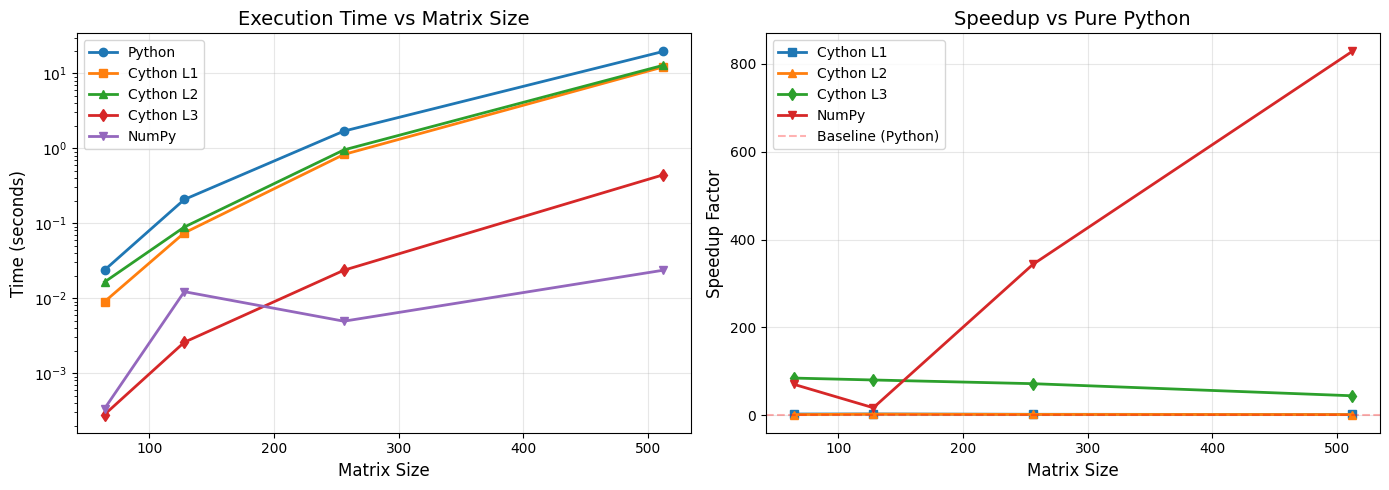

Figure saved as 'matmul_performance.png'


In [19]:
# Plot timing comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Absolute timing
ax1.plot(sizes, python_times, 'o-', label='Python', linewidth=2)
ax1.plot(sizes, cython_level1_times, 's-', label='Cython L1', linewidth=2)
ax1.plot(sizes, cython_level2_times, '^-', label='Cython L2', linewidth=2)
ax1.plot(sizes, cython_level3_times, 'd-', label='Cython L3', linewidth=2)
ax1.plot(sizes, numpy_times, 'v-', label='NumPy', linewidth=2)
ax1.set_xlabel('Matrix Size', fontsize=12)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time vs Matrix Size', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Speedup comparison
ax2.plot(sizes, df['Speedup L1'], 's-', label='Cython L1', linewidth=2)
ax2.plot(sizes, df['Speedup L2'], '^-', label='Cython L2', linewidth=2)
ax2.plot(sizes, df['Speedup L3'], 'd-', label='Cython L3', linewidth=2)
ax2.plot(sizes, df['Speedup NumPy'], 'v-', label='NumPy', linewidth=2)
ax2.axhline(y=1, color='r', linestyle='--', alpha=0.3, label='Baseline (Python)')
ax2.set_xlabel('Matrix Size', fontsize=12)
ax2.set_ylabel('Speedup Factor', fontsize=12)
ax2.set_title('Speedup vs Pure Python', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('matmul_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved as 'matmul_performance.png'")

### Reflection Questions

Answer the following questions based on your results. Write 2-3 sentences for each.

#### Q1: What was the speedup from Level 1 (basic Cython) compared to pure Python?

**Your Answer:**
Level 1 was only a bit faster than pure python, roughly around 1.5x in my tests.

#### Q2: What additional speedup did you get from adding type declarations (Level 2)?

**Your Answer:**
Level 2 gave a noticeably bigger speedup, around 3x to 5x times faster than pure python version. 

#### Q3: Why did Level 3 (memory views) provide the biggest speedup?

**Your Answer:**
Level 3 was the fastest, because memory views let cython access numpy array data directly at C level. It removes all the overhead, like bounds checking and object lookups.

#### Q4: How does your best Cython implementation compare to NumPy? Why is NumPy still faster?

**Your Answer:**
My fastest cython version comes close, but numpy is still faster. Because numpy uses highly optimized BLAS routines underneath, which are written in low-level C and assembly. They take advantage of things like better cache usage, vectorized SIMD instructions, and year of tuning.

#### Q5: When would you use Cython instead of NumPy for numerical computing?

**Your Answer:**
I’d use cython when I need a custom algorithm that numpy doesn’t provide, or when the logic involves loops and can’t be easily expressed with vectorized numpy operations. It’s also useful when combining python with low-level C code or when I need more control over performance.

#### Q6: What are the trade-offs of using Cython? (Consider development time, debugging, portability)

**Your Answer:**
The main trade-offs are that cython takes more time to write and debug, and we have to deal with compilation and C toolchains. It’s also less portable than pure python. But the benefit is that we get much better performance when we really need it.

---

## Submission Checklist

Before submitting, verify:

- [ ] All code cells have been executed (outputs are visible)
- [ ] All four Cython levels are implemented
- [ ] Timing results are present for all test cases
- [ ] Summary table is generated
- [ ] Visualization is displayed
- [ ] All six reflection questions are answered
- [ ] Used "Restart & Run All" before submission

**Submit this notebook (.ipynb file) with all outputs visible.**